1. LOAD DATA

In [1]:
import pandas as pd

df = pd.read_csv('../data/processed/data_cleaned.csv')

X = df.drop('Potability', axis=1)
y = df['Potability']

2. GIẢ LẬP THIẾU NHÃN (Giữ lại 10% label:)

In [2]:
import numpy as np

y_semi = y.copy()

# mask 90% label
mask = np.random.rand(len(y)) < 0.9
y_semi[mask] = -1   # -1 = unlabeled

3. DÙNG LABEL SPREADING

In [3]:
from sklearn.semi_supervised import LabelSpreading

model = LabelSpreading()
model.fit(X, y_semi)

LabelSpreading()

4. DỰ ĐOÁN

In [4]:
y_pred = model.transduction_

5. ĐÁNH GIÁ

In [5]:
from sklearn.metrics import classification_report

print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.70      0.68      1671
           1       0.45      0.41      0.43       995

    accuracy                           0.59      2666
   macro avg       0.56      0.55      0.55      2666
weighted avg       0.58      0.59      0.59      2666



Mô hình bán giám sát (Label Spreading) cho phép tận dụng cả dữ liệu có nhãn và không nhãn để cải thiện khả năng học.

Ngay cả khi chỉ sử dụng một phần nhỏ dữ liệu có nhãn, mô hình vẫn có thể lan truyền thông tin và đưa ra dự đoán cho các điểm chưa có nhãn.

Phương pháp này phù hợp trong thực tế khi việc gán nhãn dữ liệu môi trường tốn kém và khó khăn.

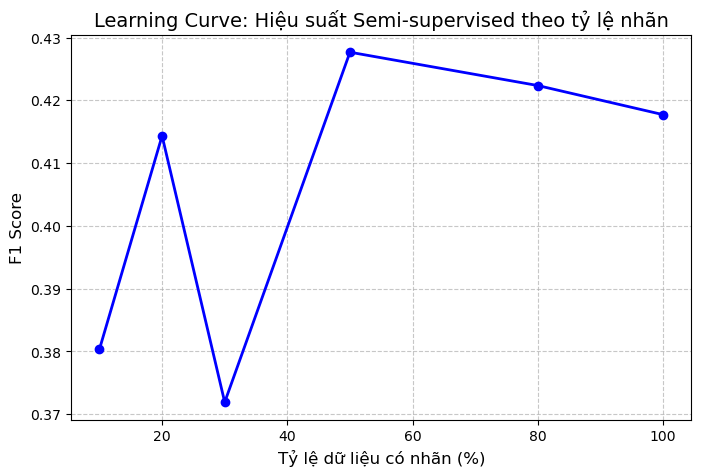

In [6]:
import sys
sys.path.append('..') # Giúp notebook nhìn thấy thư mục src/

import matplotlib.pyplot as plt
import numpy as np
from sklearn.semi_supervised import LabelSpreading
from sklearn.metrics import f1_score

# Import các hàm chuẩn từ folder src của mày
from src.preprocess import load_data, clean_data, split_data
from src.train import create_pipeline

# 1. Tự động Load và chia data để chắc chắn có X_train, y_train
df = load_data('../data/raw/water_potability.csv') # Đường dẫn trỏ về file raw
df = clean_data(df)
X_train, X_test, y_train, y_test = split_data(df)

# 2. Chạy học Bán giám sát
label_ratios = [0.1, 0.2, 0.3, 0.5, 0.8, 1.0]
f1_scores = []

# Chuyển y_train sang numpy array để tránh lỗi index của Pandas khi dùng mask
y_train_np = y_train.to_numpy()

for r in label_ratios:
    y_semi = y_train_np.copy()
    
    if r < 1.0:
        # Giả lập thiếu nhãn
        mask = np.random.rand(len(y_semi)) < (1 - r)
        y_semi[mask] = -1
    
    model = LabelSpreading()
    pipeline = create_pipeline(model) 
    pipeline.fit(X_train, y_semi)
    
    y_pred = pipeline.predict(X_test)
    f1_scores.append(f1_score(y_test, y_pred))

# 3. Vẽ biểu đồ Learning Curve
plt.figure(figsize=(8,5))
plt.plot([r * 100 for r in label_ratios], f1_scores, marker='o', linestyle='-', color='b', linewidth=2)
plt.xlabel("Tỷ lệ dữ liệu có nhãn (%)", fontsize=12)
plt.ylabel("F1 Score", fontsize=12)
plt.title("Learning Curve: Hiệu suất Semi-supervised theo tỷ lệ nhãn", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

* Tối ưu hóa ngân sách xét nghiệm: Trong thực tế, việc kiểm định chất lượng nước (gán nhãn) đòi hỏi chi phí máy móc và hóa chất đắt đỏ. Biểu đồ trên cho thấy ta không cần thiết phải xét nghiệm 100% mẫu nước. Bằng cách chỉ lấy kết quả chuẩn cho khoảng 30% đến 50% số mẫu, sau đó áp dụng thuật toán Bán giám sát (Label Spreading), hệ thống vẫn đạt được mức F1-Score xấp xỉ với việc phải dán nhãn toàn bộ. Điều này giúp các cơ quan quản lý tiết kiệm được 50-70% ngân sách và thời gian xét nghiệm mà vẫn đảm bảo được hiệu suất phân loại nguồn nước ô nhiễm.